# FASE 4 — Análise Exploratória de Dados (EDA)

Este notebook realiza a exploração do dataset `netflix_featured.csv`, gerado na Fase 3 (Transformação).  
O objetivo é identificar padrões, distribuições e relações entre variáveis, validando a qualidade dos dados preparados nas etapas anteriores.

---

## 0. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Diretório de saída para gráficos
os.makedirs('../graficos', exist_ok=True)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 1. Carregamento do Dataset

In [2]:
df = pd.read_csv('../dados_intermediarios/netflix_featured.csv')

print(f"Dimensões do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df.head()

Dimensões do dataset: 8,790 linhas × 22 colunas


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,...,qtd_generos,idade_conteudo,decada_lancamento,mes_adicao,ano_adicao,indicador_filme_serie,faixa_duracao,categoria_idade,duration_minmax,idade_standardized
0,s1287,Movie,Classmates Minus,Huang Hsin-Yao,Taiwan,2021-02-20,2020.0,NaN,123 min,"Comedies, Dramas, Independent Movies",...,3,6.0,2020.0s,2.0,2021.0,1,Longo,Novo,0.388350,-0.656100
1,s5310,Movie,Sohni Mahiwal,"Latif Faiziyev, Umesh Mehra",India,2017-09-01,1984.0,TV-14,160 min,"Dramas, International Movies, Romantic Movies",...,3,42.0,1980.0s,9.0,2017.0,1,Longo,Antigo,0.508091,3.426031
2,s6753,Movie,Filosofi Kopi The Movie,Angga Dwimas Sasongko,Indonesia,2018-10-11,2015.0,TV-PG,118 min,"Dramas, International Movies",...,2,11.0,2010.0s,10.0,2018.0,1,Médio,Intermediário,0.372168,-0.089138
3,s3037,TV Show,Jamtara - Sabka Number Ayega,Soumendra Padhi,NaN,2020-01-10,2020.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas",...,3,6.0,2020.0s,1.0,2020.0,0,Série (Temporadas),Novo,NaN,-0.656100
4,s4339,Movie,Don't Go Breaking My Heart 2,NaN,Hong Kong,2018-12-01,2014.0,NaN,113 min,"Comedies, International Movies, Romantic Movies",...,3,12.0,2010.0s,12.0,2018.0,1,Médio,Antigo,0.355987,0.024255


## 2. Estatísticas Descritivas

Visão geral das variáveis numéricas principais: **duration_num** (duração de filmes em minutos)  
e **idade_conteudo** (anos desde o lançamento até a adição na plataforma).

In [3]:
# Filmes separados para duration_num (TV Shows usam Season, escala diferente)
filmes = df[df['type'] == 'Movie'].copy()
series = df[df['type'] == 'TV Show'].copy()

vars_desc = df[['duration_num', 'idade_conteudo', 'release_year', 'qtd_generos']].describe().T
vars_desc.columns = ['count', 'média', 'desvio_pad', 'min', 'Q1', 'mediana', 'Q3', 'max']
vars_desc = vars_desc.round(2)

print("=== Estatísticas Descritivas Gerais ===")
display(vars_desc)

=== Estatísticas Descritivas Gerais ===


,count,média,desvio_pad,min,Q1,mediana,Q3,max
duration_num,8790.0,69.93,50.79,1.0,2.0,88.5,106.0,312.0
idade_conteudo,8775.0,11.79,8.82,1.0,7.0,9.0,13.0,101.0
release_year,8775.0,2014.21,8.82,1925.0,2013.0,2017.0,2019.0,2025.0
qtd_generos,8790.0,2.19,0.78,1.0,2.0,2.0,3.0,3.0


In [4]:
# Estatísticas separadas: duração de filmes vs número de temporadas (séries)
print("=== Duração dos Filmes (minutos) ===")
print(filmes['duration_num'].describe().rename({
    'count':'contagem', 'mean':'média', 'std':'desvio_pad',
    'min':'mínimo', '25%':'Q1', '50%':'mediana', '75%':'Q3', 'max':'máximo'
}).round(2).to_string())

print()
print("=== Número de Temporadas (Séries) ===")
print(series['duration_num'].describe().rename({
    'count':'contagem', 'mean':'média', 'std':'desvio_pad',
    'min':'mínimo', '25%':'Q1', '50%':'mediana', '75%':'Q3', 'max':'máximo'
}).round(2).to_string())

=== Duração dos Filmes (minutos) ===
contagem      6126.00
média           99.58
desvio_pad      28.28
mínimo           3.00
Q1              87.00
mediana         98.00
Q3             114.00
máximo         312.00

=== Número de Temporadas (Séries) ===
contagem      2663.00
média            1.75
desvio_pad       1.55
mínimo           1.00
Q1               1.00
mediana          1.00
Q3               2.00
máximo          17.00


> **Interpretação:**  
> - A duração média dos filmes é ~100 minutos, com mediana em 98 min — distribuição levemente assimétrica.  
> - O percentil 75 está em 114 min, indicando que a maioria dos filmes está entre 87 e 114 min.  
> - A `idade_conteudo` mediana de 9 anos mostra que o catálogo é majoritariamente de conteúdo relativamente recente.

## 3. Frequência de Variáveis Categóricas

In [5]:
# 3.1 Filmes vs Séries
type_counts = df['type'].value_counts()
print("=== Distribuição por Tipo ===")
print(type_counts.to_string())
print(f"\nProporção Filmes: {type_counts['Movie']/len(df)*100:.1f}%")
print(f"Proporção Séries: {type_counts['TV Show']/len(df)*100:.1f}%")

=== Distribuição por Tipo ===
type
Movie      6126
TV Show    2663

Proporção Filmes: 69.7%
Proporção Séries: 30.3%


In [6]:
# 3.2 Top 10 países com mais conteúdo
country_top = df['country'].value_counts().head(10)
print("=== Top 10 Países por Volume de Conteúdo ===")
print(country_top.to_string())

=== Top 10 Países por Volume de Conteúdo ===
country
United States     2753
India              798
United Kingdom     495
Pakistan           352
Canada             239
Japan              225
South Korea        186
France             179
Spain              150
Mexico             115


In [7]:
# 3.3 Classificação indicativa
rating_counts = df['rating'].value_counts()
print("=== Classificação Indicativa (rating) ===")
print(rating_counts.to_string())

=== Classificação Indicativa (rating) ===
rating
TV-MA       2707
TV-14       1856
TV-PG        739
R            660
PG-13        415
TV Show      383
TV-Y7        280
TV-Y         262
PG           250
TV-G         182
NR            61
G             35
Movie         15
TV-Y7-FV       3
UR             2
NC-17          2


In [8]:
# 3.4 Faixa de duração
faixa_counts = df['faixa_duracao'].value_counts()
print("=== Faixa de Duração ===")
print(faixa_counts.to_string())

=== Faixa de Duração ===
faixa_duracao
Médio                 4498
Série (Temporadas)    2663
Longo                 1142
Curto                  487


In [9]:
# 3.5 Década de lançamento
decada_counts = df['decada_lancamento'].value_counts().sort_index()
print("=== Conteúdos por Década de Lançamento ===")
print(decada_counts.to_string())

=== Conteúdos por Década de Lançamento ===
decada_lancamento
1920.0s       1
1940.0s      15
1950.0s      11
1960.0s      25
1970.0s      69
1980.0s     128
1990.0s     272
2000.0s     805
2010.0s    5891
2020.0s    1558


## 4. Gráficos de Distribuição

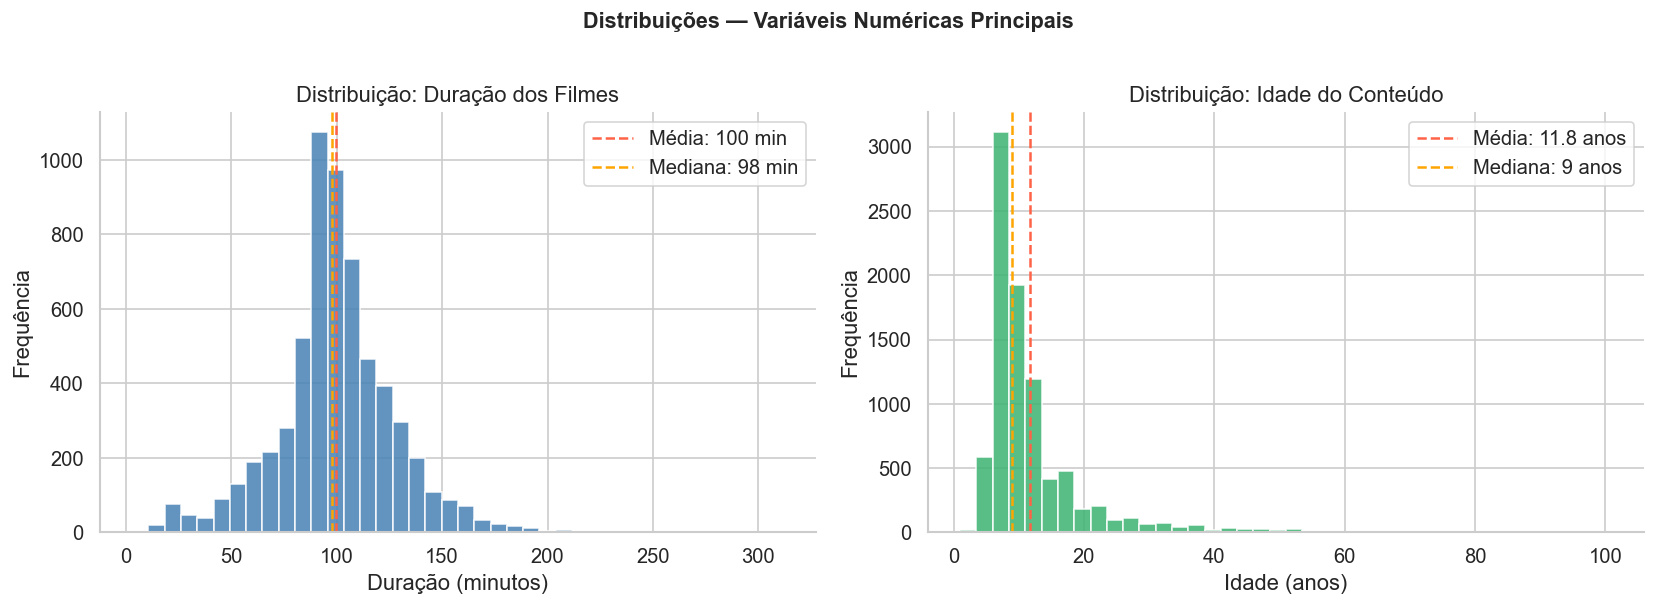

Gráfico salvo em graficos/04_01_histogramas_numericas.png


In [10]:
# 4.1 Histograma: Duração dos Filmes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(filmes['duration_num'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(filmes['duration_num'].mean(), color='tomato', linestyle='--', linewidth=1.5, label=f"Média: {filmes['duration_num'].mean():.0f} min")
axes[0].axvline(filmes['duration_num'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Mediana: {filmes['duration_num'].median():.0f} min")
axes[0].set_title("Distribuição: Duração dos Filmes")
axes[0].set_xlabel("Duração (minutos)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Histograma: idade_conteudo
axes[1].hist(df['idade_conteudo'].dropna(), bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(df['idade_conteudo'].mean(), color='tomato', linestyle='--', linewidth=1.5, label=f"Média: {df['idade_conteudo'].mean():.1f} anos")
axes[1].axvline(df['idade_conteudo'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Mediana: {df['idade_conteudo'].median():.0f} anos")
axes[1].set_title("Distribuição: Idade do Conteúdo")
axes[1].set_xlabel("Idade (anos)")
axes[1].set_ylabel("Frequência")
axes[1].legend()

plt.suptitle("Distribuições — Variáveis Numéricas Principais", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../graficos/04_01_histogramas_numericas.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_01_histogramas_numericas.png")

> **Interpretação:**  
> - A duração dos filmes apresenta distribuição aproximadamente normal com leve cauda à direita (filmes muito longos).  
> - A `idade_conteudo` é fortemente assimétrica: a maioria dos conteúdos tem menos de 15 anos, com uma cauda longa representando títulos clássicos.

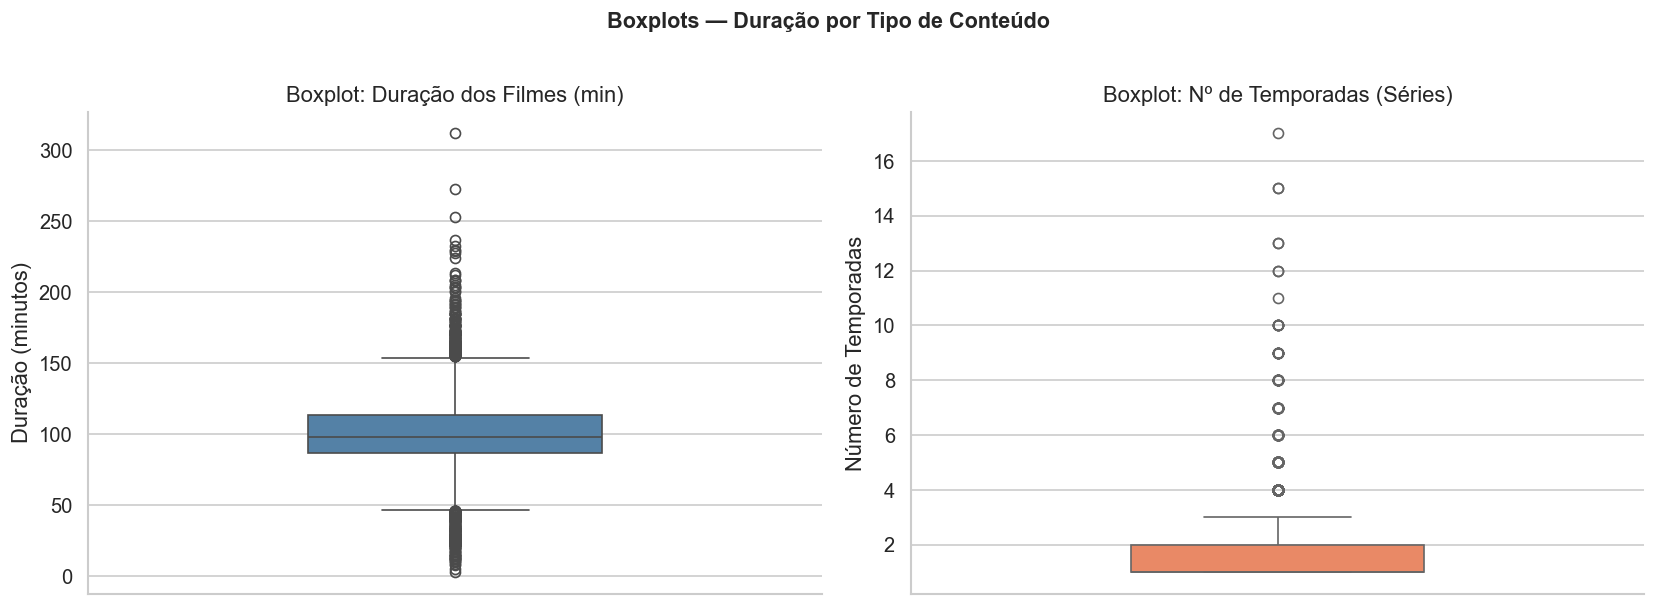

Gráfico salvo em graficos/04_02_boxplots_duracao.png


In [11]:
# 4.2 Boxplots: Duração por Tipo de Conteúdo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot duração filmes
sns.boxplot(data=filmes, y='duration_num', ax=axes[0], color='steelblue', width=0.4)
axes[0].set_title("Boxplot: Duração dos Filmes (min)")
axes[0].set_ylabel("Duração (minutos)")
axes[0].set_xlabel("")

# Boxplot temporadas séries
sns.boxplot(data=series, y='duration_num', ax=axes[1], color='coral', width=0.4)
axes[1].set_title("Boxplot: Nº de Temporadas (Séries)")
axes[1].set_ylabel("Número de Temporadas")
axes[1].set_xlabel("")

plt.suptitle("Boxplots — Duração por Tipo de Conteúdo", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../graficos/04_02_boxplots_duracao.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_02_boxplots_duracao.png")

> **Interpretação:**  
> - O boxplot dos filmes mostra outliers superiores (filmes acima de ~180 min), mas a dispersão central é controlada.  
> - Séries têm mediana em 1-2 temporadas, com poucos títulos chegando a 10+ temporadas (outliers esperados para franquias consolidadas).

## 5. Análise Temporal

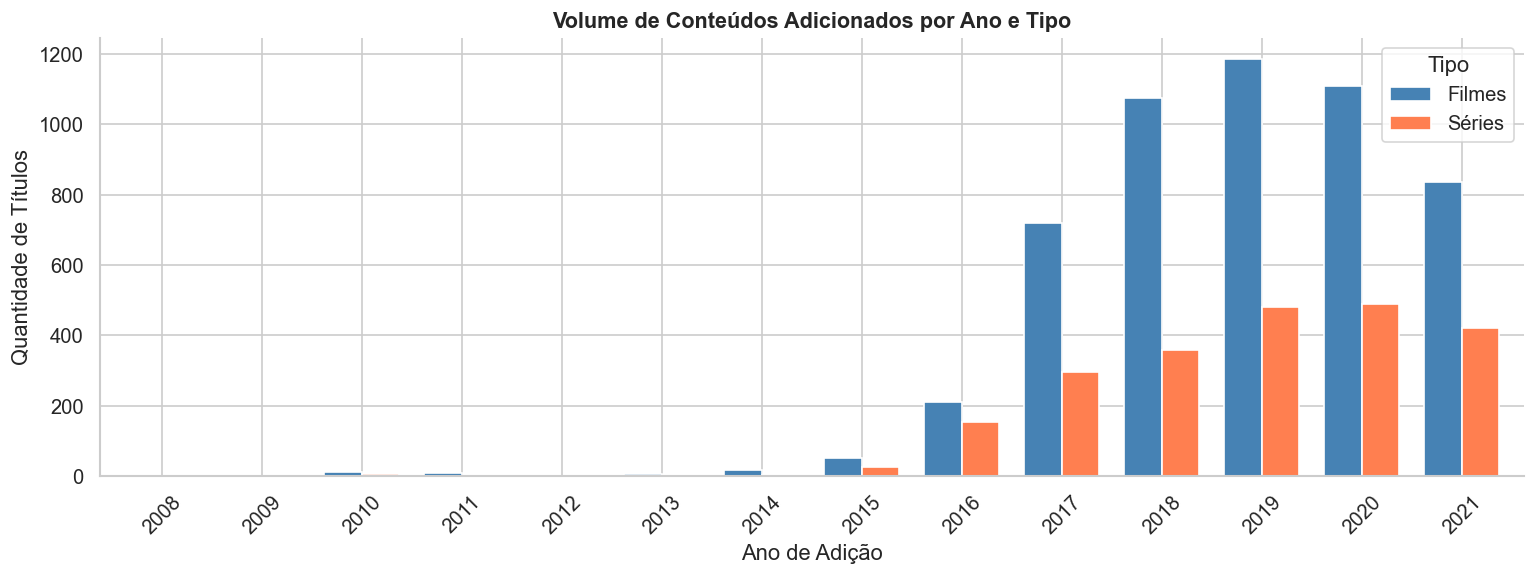

Gráfico salvo em graficos/04_03_conteudos_por_ano_tipo.png


In [12]:
# 5.1 Crescimento de conteúdos ao longo dos anos de adição
ano_tipo = df.groupby(['ano_adicao', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
ano_tipo.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white', width=0.75)
ax.set_title("Volume de Conteúdos Adicionados por Ano e Tipo", fontsize=13, fontweight='bold')
ax.set_xlabel("Ano de Adição")
ax.set_ylabel("Quantidade de Títulos")
ax.legend(['Filmes', 'Séries'], title='Tipo')
ax.set_xticklabels([str(int(x)) for x in ano_tipo.index], rotation=45)
plt.tight_layout()
plt.savefig('../graficos/04_03_conteudos_por_ano_tipo.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_03_conteudos_por_ano_tipo.png")

> **Interpretação:**  
> - O catálogo da Netflix cresceu exponencialmente entre 2016 e 2019, com pico em 2019.  
> - A partir de 2020 houve leve queda, possivelmente relacionada a restrições de produção na pandemia.  
> - Filmes sempre superaram séries em volume, mas séries mostram crescimento proporcional relevante.

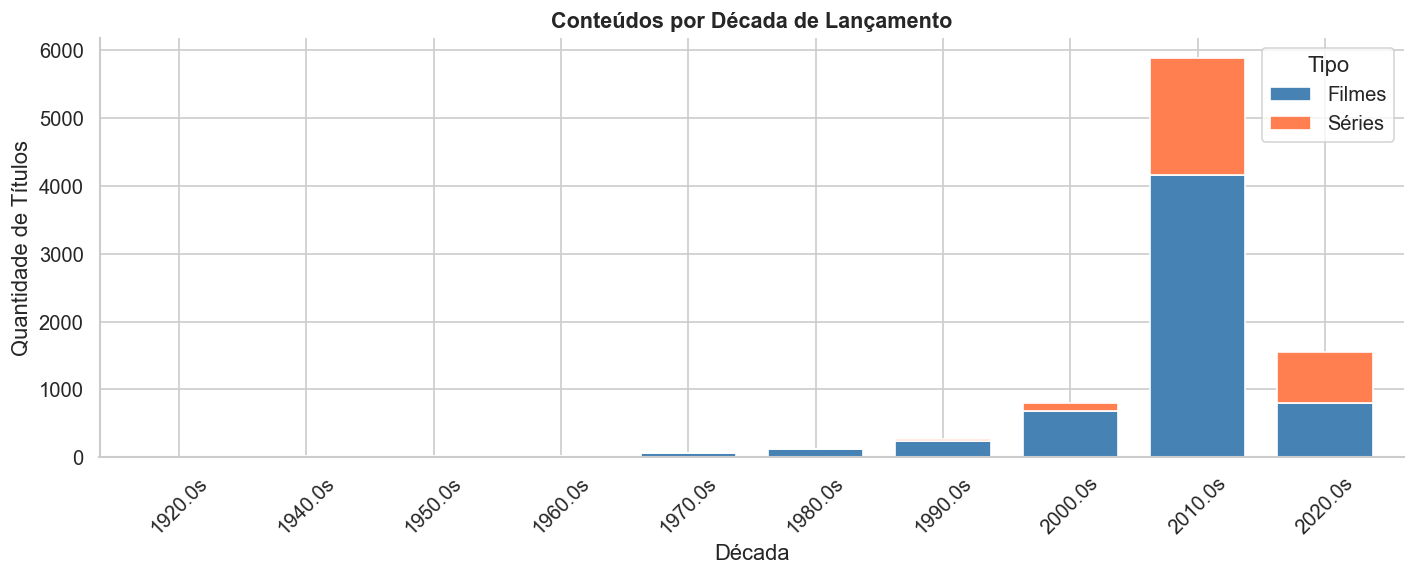

Gráfico salvo em graficos/04_04_lancamentos_por_decada.png


In [13]:
# 5.2 Distribuição de lançamentos por década
decada_tipo = df.groupby(['decada_lancamento', 'type']).size().unstack(fill_value=0).sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
decada_tipo.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white', width=0.75, stacked=True)
ax.set_title("Conteúdos por Década de Lançamento", fontsize=13, fontweight='bold')
ax.set_xlabel("Década")
ax.set_ylabel("Quantidade de Títulos")
ax.legend(['Filmes', 'Séries'], title='Tipo')
ax.set_xticklabels([str(x) for x in decada_tipo.index], rotation=45)
plt.tight_layout()
plt.savefig('../graficos/04_04_lancamentos_por_decada.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_04_lancamentos_por_decada.png")

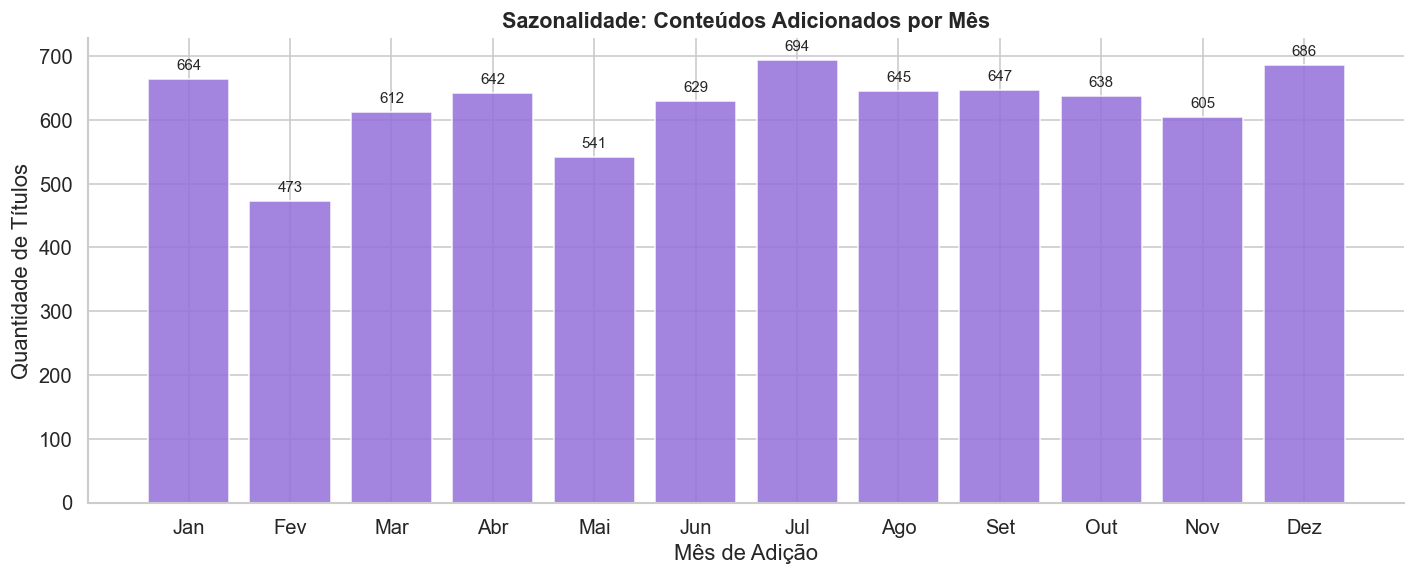

Gráfico salvo em graficos/04_05_sazonalidade_mes_adicao.png


In [14]:
# 5.3 Sazonalidade: conteúdos adicionados por mês
meses = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
         7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
mes_counts = df['mes_adicao'].value_counts().sort_index()
mes_labels = [meses[int(m)] for m in mes_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(mes_labels, mes_counts.values, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.set_title("Sazonalidade: Conteúdos Adicionados por Mês", fontsize=13, fontweight='bold')
ax.set_xlabel("Mês de Adição")
ax.set_ylabel("Quantidade de Títulos")

# rótulos nas barras
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f"{int(bar.get_height())}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../graficos/04_05_sazonalidade_mes_adicao.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_05_sazonalidade_mes_adicao.png")

> **Interpretação:**  
> - Janeiro e Julho apresentam os maiores volumes de adição, sugerindo estratégia de renovação de catálogo no início do ano e no meio do ano.  
> - Fevereiro é o mês mais fraco, compatível com menor número de dias e período pós-temporada de festas.

## 6. Análise de Categorias e Gêneros

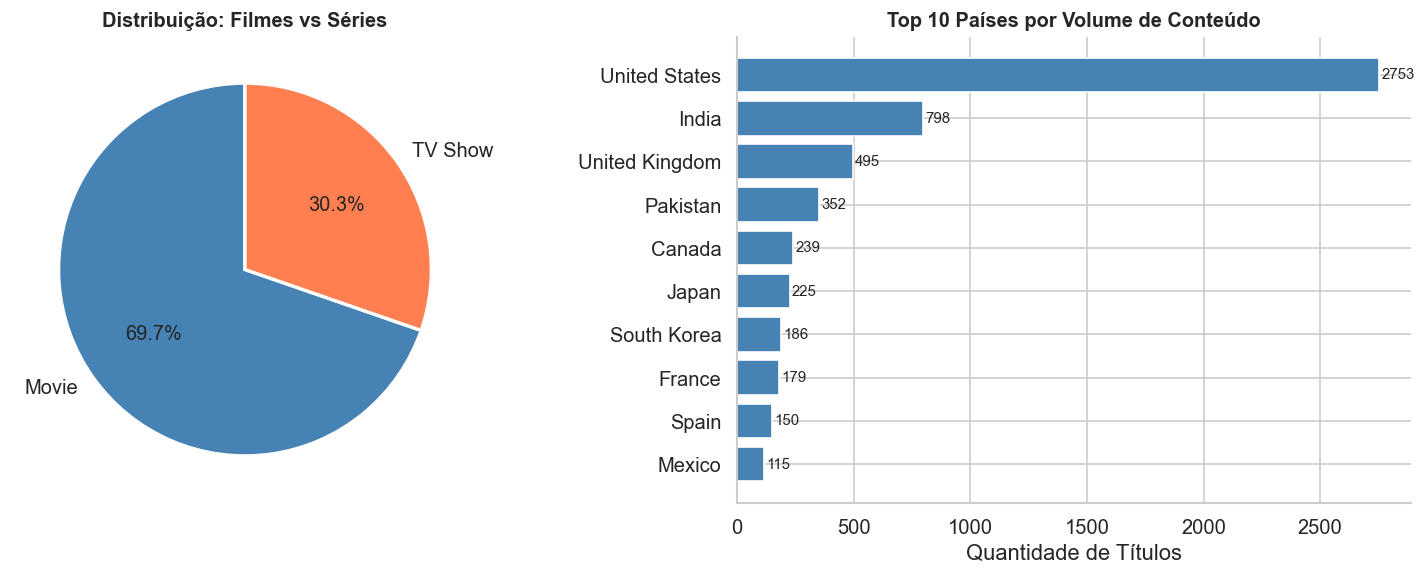

Gráfico salvo em graficos/04_06_tipo_e_paises.png


In [15]:
# 6.1 Filmes vs Séries (gráfico de pizza)
type_counts = df['type'].value_counts()
colors = ['steelblue', 'coral']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza
wedges, texts, autotexts = axes[0].pie(
    type_counts, labels=type_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(12)
axes[0].set_title("Distribuição: Filmes vs Séries", fontsize=12, fontweight='bold')

# Barras: top países
country_top10 = df['country'].value_counts().head(10)
axes[1].barh(country_top10.index[::-1], country_top10.values[::-1], color='steelblue', edgecolor='white')
axes[1].set_title("Top 10 Países por Volume de Conteúdo", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Quantidade de Títulos")
for i, v in enumerate(country_top10.values[::-1]):
    axes[1].text(v+10, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../graficos/04_06_tipo_e_paises.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_06_tipo_e_paises.png")

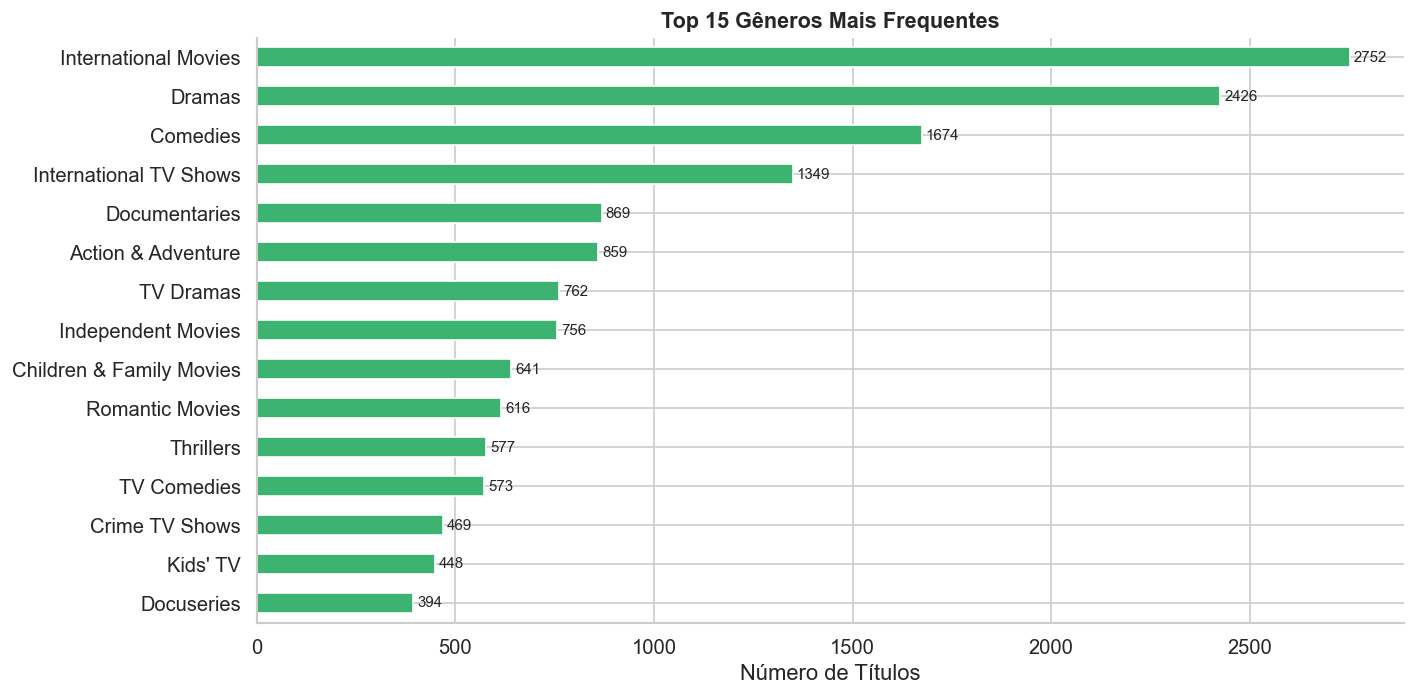

Gráfico salvo em graficos/04_07_generos_frequentes.png


In [16]:
# 6.2 Gêneros mais frequentes (explosão do campo listed_in)
generos_series = df['listed_in'].dropna().str.split(', ')
todos_generos = [g.strip() for lista in generos_series for g in lista]
genero_counts = pd.Series(todos_generos).value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
genero_counts[::-1].plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title("Top 15 Gêneros Mais Frequentes", fontsize=13, fontweight='bold')
ax.set_xlabel("Número de Títulos")
for i, v in enumerate(genero_counts.values[::-1]):
    ax.text(v+10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../graficos/04_07_generos_frequentes.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_07_generos_frequentes.png")

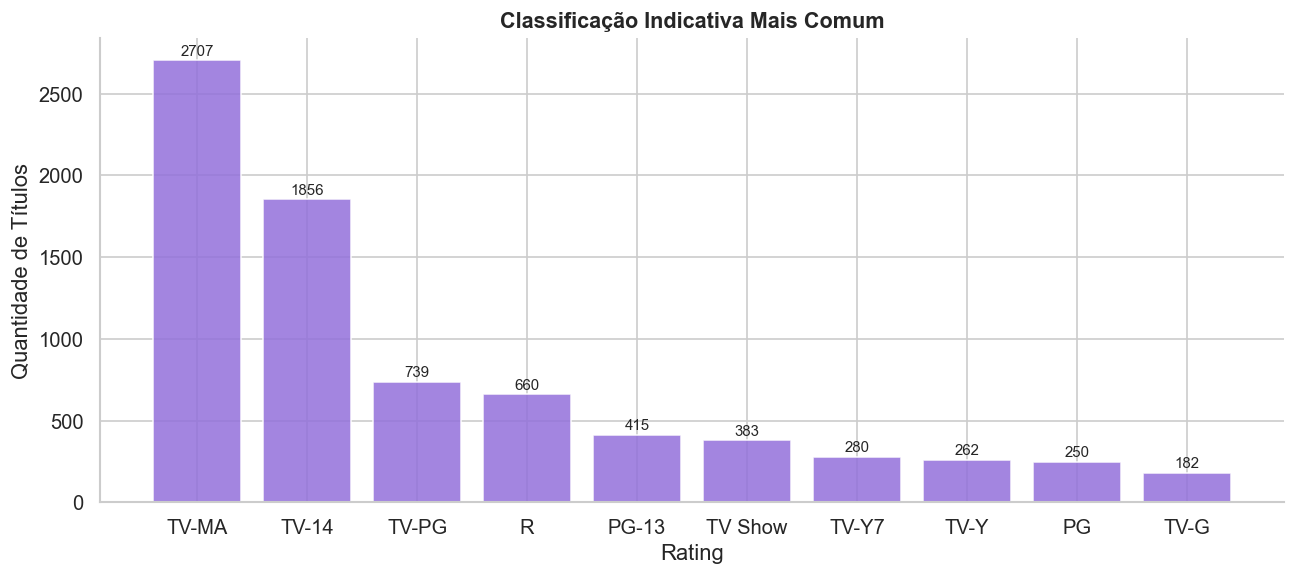

Gráfico salvo em graficos/04_08_rating_distribuicao.png


In [17]:
# 6.3 Classificação indicativa mais comum
rating_top = df['rating'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(rating_top.index, rating_top.values, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.set_title("Classificação Indicativa Mais Comum", fontsize=13, fontweight='bold')
ax.set_xlabel("Rating")
ax.set_ylabel("Quantidade de Títulos")
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f"{int(bar.get_height())}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../graficos/04_08_rating_distribuicao.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_08_rating_distribuicao.png")

> **Interpretação:**  
> - **Dramas Internacionais** e **Comedies** lideram o catálogo, refletindo a estratégia global da Netflix.  
> - **TV-MA** e **TV-14** dominam as classificações, indicando foco em audiência adulta e jovem adulta.  
> - Os EUA lideram com ~31% do catálogo; Índia é o segundo maior produtor, evidenciando a aposta da plataforma no mercado sul-asiático.

## 7. Análise de Outliers

In [18]:
# 7.1 Cálculo via IQR
def analise_iqr(serie, nome):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"--- {nome} ---")
    print(f"  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"  Limite inferior: {lim_inf:.2f}  |  Limite superior: {lim_sup:.2f}")
    print(f"  Outliers encontrados: {len(outliers)} ({len(outliers)/len(serie)*100:.2f}%)")
    print()
    return outliers

out_dur   = analise_iqr(filmes['duration_num'].dropna(), "Duração dos Filmes (min)")
out_idade = analise_iqr(df['idade_conteudo'].dropna(),   "Idade do Conteúdo (anos)")
out_year  = analise_iqr(df['release_year'].dropna(),     "Ano de Lançamento")

--- Duração dos Filmes (min) ---
  Q1=87.00  Q3=114.00  IQR=27.00
  Limite inferior: 46.50  |  Limite superior: 154.50
  Outliers encontrados: 449 (7.33%)

--- Idade do Conteúdo (anos) ---
  Q1=7.00  Q3=13.00  IQR=6.00
  Limite inferior: -2.00  |  Limite superior: 22.00
  Outliers encontrados: 712 (8.11%)

--- Ano de Lançamento ---
  Q1=2013.00  Q3=2019.00  IQR=6.00
  Limite inferior: 2004.00  |  Limite superior: 2028.00
  Outliers encontrados: 712 (8.11%)



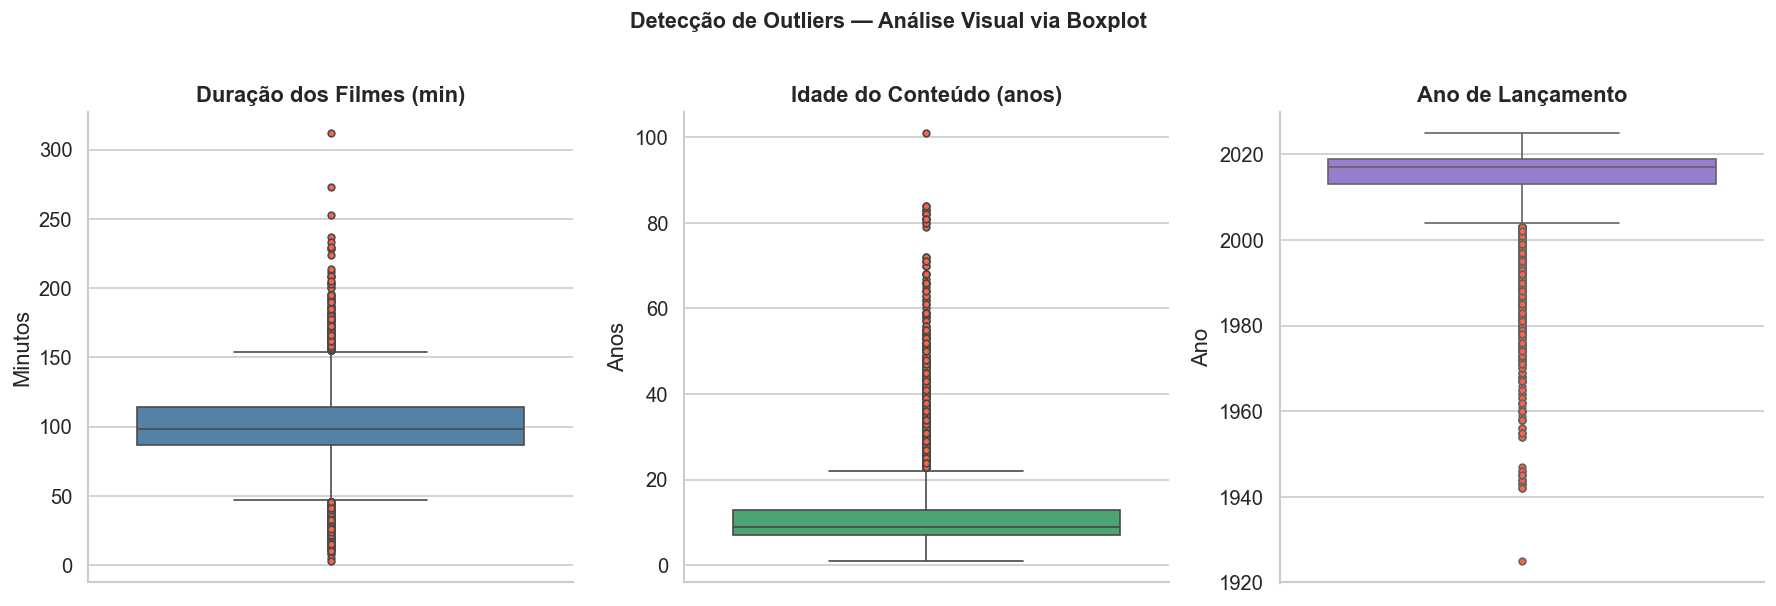

Gráfico salvo em graficos/04_09_outliers_boxplots.png


In [19]:
# 7.2 Boxplots side-by-side para identificação visual de outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=filmes['duration_num'], ax=axes[0], color='steelblue', flierprops=dict(marker='o', markerfacecolor='tomato', markersize=4))
axes[0].set_title("Duração dos Filmes (min)", fontweight='bold')
axes[0].set_ylabel("Minutos")

sns.boxplot(y=df['idade_conteudo'], ax=axes[1], color='mediumseagreen', flierprops=dict(marker='o', markerfacecolor='tomato', markersize=4))
axes[1].set_title("Idade do Conteúdo (anos)", fontweight='bold')
axes[1].set_ylabel("Anos")

sns.boxplot(y=df['release_year'], ax=axes[2], color='mediumpurple', flierprops=dict(marker='o', markerfacecolor='tomato', markersize=4))
axes[2].set_title("Ano de Lançamento", fontweight='bold')
axes[2].set_ylabel("Ano")

plt.suptitle("Detecção de Outliers — Análise Visual via Boxplot", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../graficos/04_09_outliers_boxplots.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em graficos/04_09_outliers_boxplots.png")

In [20]:
# 7.3 Conteúdos extremamente longos (top 10 filmes)
top_longos = filmes.nlargest(10, 'duration_num')[['title','release_year','duration_num','country']]
print("=== Top 10 Filmes Mais Longos ===")
display(top_longos)

# Conteúdos muito antigos
top_antigos = df.nsmallest(10, 'release_year')[['title','type','release_year','country']]
print("\n=== 10 Conteúdos Mais Antigos ===")
display(top_antigos)

=== Top 10 Filmes Mais Longos ===


,title,release_year,duration_num,country
5218,Black Mirror: Bandersnatch,2018.0,312.0,United States
344,Headspace: Unwind Your Mind,2021.0,273.0,Pakistan
689,The School of Mischief,2025.0,253.0,Egypt
388,No Longer kids,1979.0,237.0,Egypt
1313,Lock Your Girls In,1982.0,233.0,NaN
8592,Raya and Sakina,1984.0,230.0,NaN
3513,Once Upon a Time in America,1984.0,229.0,Italy
4680,Sangam,1964.0,228.0,India
8017,Lagaan,2001.0,224.0,India
7862,Jodhaa Akbar,2008.0,214.0,India



=== 10 Conteúdos Mais Antigos ===


,title,type,release_year,country
7998,Pioneers: First Women Filmmakers*,TV Show,1925.0,Pakistan
6496,The Battle of Midway,Movie,1942.0,United States
7545,Prelude to War,Movie,1942.0,United States
3435,WWII: Report from the Aleutians,Movie,1943.0,United States
4364,Undercover: How to Operate Behind Enemy Lines,Movie,1943.0,United States
5338,Why We Fight: The Battle of Russia,Movie,1943.0,NaN
1037,Tunisian Victory,Movie,1944.0,United States
3453,The Memphis Belle: A Story of a\r\nFlying Fort...,Movie,1944.0,United States
6688,The Negro Soldier,Movie,1944.0,United States
1156,San Pietro,Movie,1945.0,United States


> **Interpretação:**  
> - Filmes acima de ~180 min são outliers pelo IQR, mas fazem sentido contextualmente (documentários longos, filmes épicos).  
> - A `idade_conteudo` possui outliers superiores representando títulos clássicos (décadas de 1920-1960) — valores válidos e esperados.  
> - Não há outliers problemáticos que indiquem erros de dados; os extremos são conteúdo legítimo.

## 8. Resumo dos Principais Achados

In [21]:
resumo = {
    "Total de títulos": len(df),
    "Filmes (%)": f"{len(filmes)/len(df)*100:.1f}%",
    "Séries (%)": f"{len(series)/len(df)*100:.1f}%",
    "Duração média dos filmes (min)": f"{filmes['duration_num'].mean():.1f}",
    "Mediana duração filmes (min)": f"{filmes['duration_num'].median():.0f}",
    "Ano de lançamento médio": f"{df['release_year'].mean():.0f}",
    "Idade média do conteúdo (anos)": f"{df['idade_conteudo'].mean():.1f}",
    "País com mais conteúdo": df['country'].value_counts().index[0],
    "Rating mais comum": df['rating'].value_counts().index[0],
    "Ano com mais adições": str(int(df['ano_adicao'].value_counts().index[0])),
    "Gráficos gerados": "9 arquivos PNG em /graficos/",
}

print("=" * 50)
print("  RESUMO — FASE 4: EDA")
print("=" * 50)
for k, v in resumo.items():
    print(f"  {k:<40} {v}")
print("=" * 50)

  RESUMO — FASE 4: EDA
  Total de títulos                         8790
  Filmes (%)                               69.7%
  Séries (%)                               30.3%
  Duração média dos filmes (min)           99.6
  Mediana duração filmes (min)             98
  Ano de lançamento médio                  2014
  Idade média do conteúdo (anos)           11.8
  País com mais conteúdo                   United States
  Rating mais comum                        TV-MA
  Ano com mais adições                     2019
  Gráficos gerados                         9 arquivos PNG em /graficos/


## Conclusão da Fase 4

A análise exploratória revelou os seguintes padrões principais no dataset `netflix_featured.csv`:

- **Composição do catálogo:** ~70% filmes e ~30% séries, com forte predominância de conteúdo americano seguido por índia e Reino Unido.
- **Distribuição de duração:** filmes com duração centrada em ~98-100 minutos, distribuição levemente assimétrica à direita — comportamento esperado para longas-metragens.
- **Perfil temporal:** catálogo dominado por conteúdo dos anos 2010, com crescimento expressivo de adições entre 2016-2019 e leve retração em 2020-2021.
- **Gêneros:** Dramas e Comédias Internacionais lideram; classificação TV-MA é a mais frequente, refletindo foco em audiência adulta.
- **Outliers:** presentes em duração (filmes muito longos) e ano de lançamento (clássicos antigos), mas todos com contexto legítimo — sem evidências de erros nos dados transformados.
- **Sazonalidade:** adições concentradas em Janeiro e Julho, sugerindo estratégia editorial semestral da plataforma.

Os dados estão prontos para a próxima fase de modelagem ou análise aprofundada.